# Imports

In [1]:
import numpy as np
import pandas as pd

In [165]:
import os
import json
from pathlib import Path
from functools import reduce

In [3]:
from statsmodels.api import OLS,add_constant,graphics
from scipy.stats import norm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# import warnings
# warnings.filterwarnings("ignore")


# Importing Data

In [6]:
data_store=Path("./Prepared_Data_Store")

In [7]:
stocks_data=pd.read_csv(os.path.join(data_store,"stocks_data.csv"),parse_dates=["date"],index_col=["date","ticker"])

factor_data=pd.read_csv(os.path.join(data_store,"factor_data.csv"),parse_dates=["date"],index_col=["date"])

In [8]:
sp500_data=pd.read_csv(os.path.join(data_store,"sp500_data.csv"),parse_dates=["date"],index_col=["date"])

# Separating Features and Target Variables

In [9]:
Y=stocks_data.filter(like="forward_returns")

In [10]:
Y.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 732292 entries, (Timestamp('2010-02-22 00:00:00'), 'A') to (Timestamp('2017-11-29 00:00:00'), 'ZBRA')
Data columns (total 5 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   forward_returns_1d   732292 non-null  float64
 1   forward_returns_5d   732292 non-null  float64
 2   forward_returns_7d   732292 non-null  float64
 3   forward_returns_15d  732292 non-null  float64
 4   forward_returns_21d  732292 non-null  float64
dtypes: float64(5)
memory usage: 30.8+ MB


In [11]:
X=stocks_data.drop(Y.columns,axis=1,inplace=False)

In [12]:
X=(X
   .groupby("ticker")
   .transform(lambda x: (x-x.mean())/x.std())
   .fillna(0))

# Statistical Tests

## Various Tests

#### 1. For the coefficients of the OLS Regression the Null Hypothesis is that coefficients are equal to 0. So we want the Probability of t-test to be less than 0.05.

#### 2. R-Square tells about how well the model has performed. Value close to 1 are preferred.

#### 3. AIC and BIC are used to compare the models. Lower values are preferred.

#### 4. Log Likelihood is given the feature values how likely is that model produce the given output. Higher value of Log Likelihood are preferred.

#### 5. Omnibus Test: The Null Hypothesis of Omnibus test is that the residuals are normally distributed. We want the Null Hypothesis to hold true. Therefore the Prob(Omnibus)>0.05

#### 6. Jarque-Bera Test: It is another test for checking the normality of the residuals. It has the same Null hypothesis as that of Omnibus test.

#### 7. Durbin-Watson Test: The Durbin-Watson test checks the auto-correlation between the residuals. Value equal to 2 states no auto-correlation, value <2 states positve correlation, value >2 states negative correlation, value 0-1 highly positive correlation, value 3-4 states highly negative correlaton   

#### 8. Condition Number: The condition number gives the idea of the multicollinearity(how strongly the independent variables are related to each other). Values <30 states no strong multicollinearity, Values 30-100 states moderate multicollinearity, Values >100 states strong multicollinearity, Values >>1000 states model is unstable.

#### 9. Skew: The skew test tells about the peak of the curve that is how early or late the peak has occured from the mean. The normal distribution has skew equal to 0.

#### 10. Kurtosis: The kurtosis test is about the tails of the curve. The normal distribution has kurtosis equal to 3. Higher kurtosis value means fatter the tails of the curve are.
  

# Starting Statistical Testing

## Using only Stock Data Features

In [13]:
X.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 732292 entries, (Timestamp('2010-02-22 00:00:00'), 'A') to (Timestamp('2017-11-29 00:00:00'), 'ZBRA')
Data columns (total 76 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   open                 732292 non-null  float64
 1   high                 732292 non-null  float64
 2   low                  732292 non-null  float64
 3   close                732292 non-null  float64
 4   volume               732292 non-null  float64
 5   dollar_volume        732292 non-null  float64
 6   dollar_volume_7d     732292 non-null  float64
 7   dollar_volume_15d    732292 non-null  float64
 8   dollar_volume_21d    732292 non-null  float64
 9   dollar_volume_rank   732292 non-null  float64
 10  returns_1d           732292 non-null  float64
 11  returns_7d           732292 non-null  float64
 12  returns_15d          732292 non-null  float64
 13  returns_21d          732292 non-null  float64

### Target- 1D

In [14]:
target="forward_returns_1d"

In [15]:
model=OLS(endog=Y[target],exog=add_constant(X))
trained_model=model.fit()

In [16]:
print(trained_model.summary())

                            OLS Regression Results                            
Dep. Variable:     forward_returns_1d   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     83.02
Date:                Mon, 04 Aug 2025   Prob (F-statistic):               0.00
Time:                        15:03:05   Log-Likelihood:             1.9551e+06
No. Observations:              732292   AIC:                        -3.910e+06
Df Residuals:                  732215   BIC:                        -3.909e+06
Df Model:                          76                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0008   1

In [17]:
irrelevant_features_1d=trained_model.pvalues[trained_model.pvalues>0.05].index.tolist()

In [18]:
preds=trained_model.predict(add_constant(X))
residuals_1d=Y[target]-preds

### Target-5D

In [19]:
target="forward_returns_5d"

In [20]:
model=OLS(endog=Y[target],exog=add_constant(X))
trained_model=model.fit()
print(trained_model.summary())

                            OLS Regression Results                            
Dep. Variable:     forward_returns_5d   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     71.24
Date:                Mon, 04 Aug 2025   Prob (F-statistic):               0.00
Time:                        15:03:13   Log-Likelihood:             1.9547e+06
No. Observations:              732292   AIC:                        -3.909e+06
Df Residuals:                  732215   BIC:                        -3.908e+06
Df Model:                          76                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0008   1

In [21]:
irrelevant_features_5d=trained_model.pvalues[trained_model.pvalues>0.05].index.tolist()

In [22]:
preds=trained_model.predict(add_constant(X))
residuals_5d=Y[target]-preds

### Target-7D

In [23]:
target="forward_returns_7d"

In [24]:
model=OLS(endog=Y[target],exog=add_constant(X))
trained_model=model.fit()
print(trained_model.summary())

                            OLS Regression Results                            
Dep. Variable:     forward_returns_7d   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     54.04
Date:                Mon, 04 Aug 2025   Prob (F-statistic):               0.00
Time:                        15:03:19   Log-Likelihood:             1.9543e+06
No. Observations:              732292   AIC:                        -3.909e+06
Df Residuals:                  732215   BIC:                        -3.908e+06
Df Model:                          76                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0008   1

In [25]:
irrelevant_features_7d=trained_model.pvalues[trained_model.pvalues>0.05].index.tolist()

In [26]:
preds=trained_model.predict(add_constant(X))
residuals_7d=Y[target]-preds

### Target-15D


In [27]:
target="forward_returns_15d"

In [28]:
model=OLS(endog=Y[target],exog=add_constant(X))
trained_model=model.fit()
print(trained_model.summary())

                             OLS Regression Results                            
Dep. Variable:     forward_returns_15d   R-squared:                       0.006
Model:                             OLS   Adj. R-squared:                  0.006
Method:                  Least Squares   F-statistic:                     59.47
Date:                 Mon, 04 Aug 2025   Prob (F-statistic):               0.00
Time:                         15:03:26   Log-Likelihood:             1.9547e+06
No. Observations:               732292   AIC:                        -3.909e+06
Df Residuals:                   732215   BIC:                        -3.908e+06
Df Model:                           76                                         
Covariance Type:             nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   

In [29]:
irrelevant_features_15d=trained_model.pvalues[trained_model.pvalues>0.05].index.tolist()

In [30]:
preds=trained_model.predict(add_constant(X))
residuals_15d=Y[target]-preds

### Target-21D

In [31]:
target="forward_returns_21d"

model=OLS(endog=Y[target],exog=add_constant(X))
trained_model=model.fit()
print(trained_model.summary())

In [32]:
preds=trained_model.predict(add_constant(X))
residuals_21d=Y[target]-preds

In [33]:
irrelevant_features_21d=trained_model.pvalues[trained_model.pvalues>0.05].index.tolist()

### Key Insights:

#### 1. The R-squared and the adj.R-squared are pretty low stating that our model has underperformed.
#### 2. The Prob(Omnibus) and the Prob(JB) is nearly equal to 0 stating that the residuals are not normally distributed hence violating the assumption.
#### 3. The value of Durbin Watson is clearly less than 2 and also not between 0-1 stating that there is some moderate positive correlation between the residuals.
#### 4. The Cond. Number is 841 which is pretty high stating that the independent features are highly correlated. Not a good sign.
#### 5. The skew value is nearly equal to 0.01 which is pretty close to 0 the skew value for normal distribution.
#### 6. The kurtosis value is greater than 10 stating that the tails are fatter and the distribution of the residuals do not follow normal distribution.
#### 7. For different target we came across different features that have t-test probability for coefficients greater than 0.05. So these features hold the null hypothesis and can be assumed as irrelevant for the model prediction.


### Irrelevant Features

#### Target-1D

In [34]:
irrelevant_features_1d

['dollar_volume',
 'dollar_volume_7d',
 'dollar_volume_15d',
 'returns_7d',
 'returns_15d',
 'returns_1d_lag5',
 'returns_7d_lag5',
 'returns_7d_lag7',
 'returns_15d_lag1',
 'returns_15d_lag3',
 'returns_15d_lag5',
 'returns_15d_lag7',
 'returns_21d_lag3',
 'returns_21d_lag7',
 'momentum_15d',
 'momentum_7d_lag5',
 'momentum_7d_lag7',
 'momentum_15d_lag1',
 'momentum_15d_lag3',
 'momentum_15d_lag5',
 'momentum_21d_lag3',
 'momentum_21d_lag5',
 'momentum_21d_lag7',
 'volatility_7d',
 'volatility_7d_lag1',
 'volatility_7d_lag3',
 'volatility_15d_lag3',
 'volatility_21d_lag7',
 'sma_15d',
 'sma_21d',
 'min_price_21d',
 'max_price_15d',
 'max_price_21d']

#### Target-5D

In [35]:
irrelevant_features_5d

['close',
 'dollar_volume',
 'returns_15d',
 'returns_7d_lag1',
 'returns_7d_lag3',
 'returns_7d_lag5',
 'returns_15d_lag1',
 'returns_15d_lag5',
 'returns_21d_lag3',
 'returns_21d_lag5',
 'momentum_7d',
 'momentum_15d',
 'momentum_7d_lag3',
 'momentum_7d_lag5',
 'momentum_15d_lag1',
 'momentum_21d_lag3',
 'momentum_21d_lag5',
 'volatility_21d',
 'volatility_7d_lag1',
 'max_price_7d',
 'max_price_15d',
 'max_price_21d',
 'bb_lower',
 'bb_upper']

#### Target-7D

In [36]:
irrelevant_features_7d

['low',
 'dollar_volume_7d',
 'dollar_volume_15d',
 'returns_1d',
 'returns_21d',
 'returns_1d_lag3',
 'returns_7d_lag1',
 'returns_7d_lag3',
 'returns_15d_lag3',
 'returns_15d_lag5',
 'returns_21d_lag1',
 'returns_21d_lag3',
 'returns_21d_lag7',
 'momentum_7d',
 'momentum_21d',
 'momentum_7d_lag3',
 'momentum_15d_lag5',
 'momentum_21d_lag3',
 'momentum_21d_lag7',
 'volatility_7d',
 'volatility_15d',
 'volatility_21d',
 'volatility_7d_lag3',
 'volatility_7d_lag5',
 'volatility_21d_lag7',
 'max_price_7d',
 'macd',
 'macd_hist',
 'macd_signal']

#### Target-15D

In [37]:
irrelevant_features_15d

['volume',
 'dollar_volume_21d',
 'returns_7d',
 'returns_21d',
 'returns_1d_lag1',
 'returns_1d_lag7',
 'returns_7d_lag3',
 'returns_15d_lag1',
 'returns_15d_lag5',
 'returns_21d_lag3',
 'momentum_7d',
 'momentum_15d_lag5',
 'momentum_21d_lag3',
 'momentum_21d_lag5',
 'volatility_21d',
 'volatility_15d_lag5',
 'volatility_21d_lag1',
 'volatility_21d_lag3',
 'min_price_21d',
 'max_price_7d',
 'max_price_15d',
 'rsi',
 'avg_true_range']

#### Target-21D

In [38]:
irrelevant_features_21d

['volume',
 'dollar_volume_21d',
 'returns_7d',
 'returns_21d',
 'returns_1d_lag1',
 'returns_1d_lag7',
 'returns_7d_lag3',
 'returns_15d_lag1',
 'returns_15d_lag5',
 'returns_21d_lag3',
 'momentum_7d',
 'momentum_15d_lag5',
 'momentum_21d_lag3',
 'momentum_21d_lag5',
 'volatility_21d',
 'volatility_15d_lag5',
 'volatility_21d_lag1',
 'volatility_21d_lag3',
 'min_price_21d',
 'max_price_7d',
 'max_price_15d',
 'rsi',
 'avg_true_range']

#### Common Irrelevant Features for all the Target Variables

In [39]:
irr_features=[irrelevant_features_1d,
              irrelevant_features_5d,
              irrelevant_features_7d,
              irrelevant_features_15d,
              irrelevant_features_21d,]

In [40]:
irrelevant_features_common=list(reduce(lambda x,y:set(x).intersection(y),irr_features))

In [41]:
irrelevant_features_common

['returns_15d_lag5', 'returns_21d_lag3', 'momentum_21d_lag3']

### Residual Plots

In [42]:
residuals=[residuals_1d,
           residuals_5d,
           residuals_7d,
           residuals_15d,
           residuals_21d,]

In [43]:
target=['1d','5d','7d','15d','21d']

Plot 1 plotted
Plot 2 plotted
Plot 3 plotted
Plot 4 plotted
Plot 5 plotted


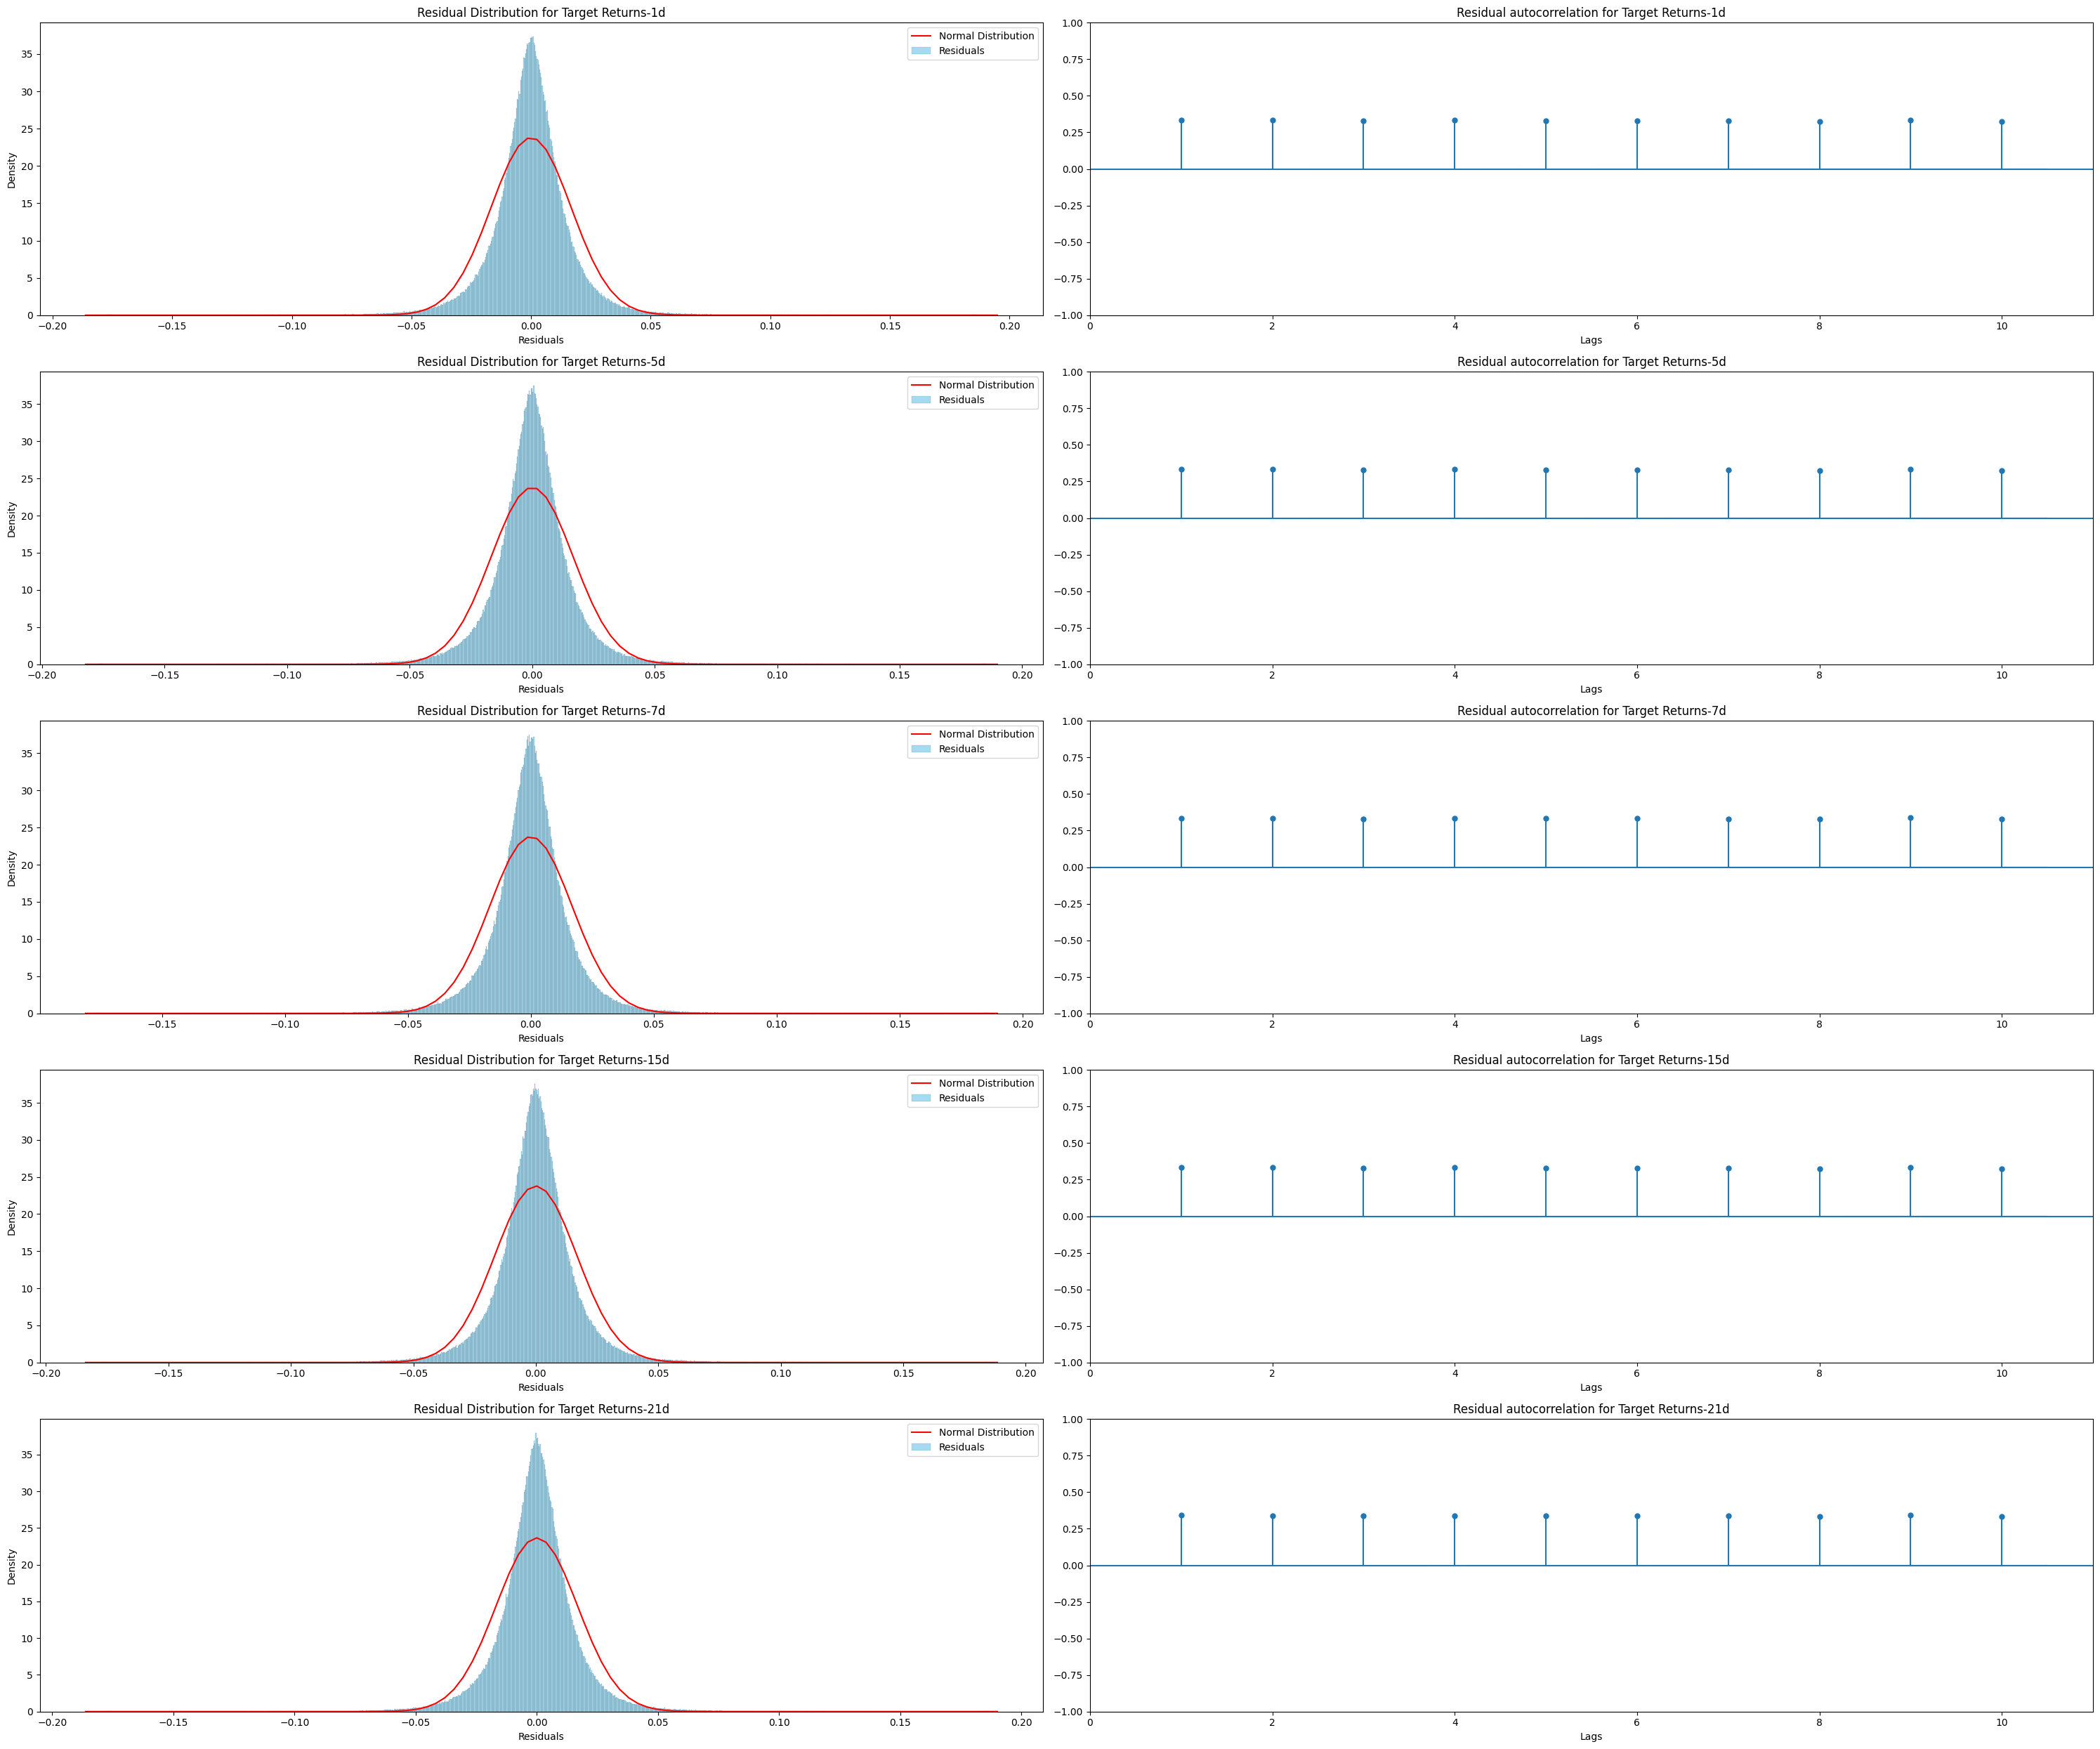

In [44]:
fig,ax=plt.subplots(nrows=5,ncols=2,figsize=(30,25))
ind=0
for t,residual in list(zip(target,residuals)):
    mu,std=norm.fit(residual)
    x=np.linspace(min(residual),max(residual),100)
    y=norm.pdf(x,mu,std)

    sns.histplot(residual,stat="density",ax=ax[ind,0],label="Residuals",color="skyblue")
    ax[ind,0].plot(x,y,"r",label="Normal Distribution")
    ax[ind,0].legend()
    ax[ind, 0].set_title(f"Residual Distribution for Target Returns-{t}")
    ax[ind, 0].set_xlabel("Residuals")


    
    plot_acf(residual,zero=False,lags=10,ax=ax[ind,1],title=f"Residual autocorrelation for Target Returns-{t}")
    ax[ind,1].set_xlabel("Lags")
    
    print(f"Plot {ind+1} plotted")
    ind+=1
    
fig.tight_layout()
plt.show()

### Removing Irrelevant Features

#### Removing Common Irrelevant Features

In [45]:
X.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 732292 entries, (Timestamp('2010-02-22 00:00:00'), 'A') to (Timestamp('2017-11-29 00:00:00'), 'ZBRA')
Data columns (total 76 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   open                 732292 non-null  float64
 1   high                 732292 non-null  float64
 2   low                  732292 non-null  float64
 3   close                732292 non-null  float64
 4   volume               732292 non-null  float64
 5   dollar_volume        732292 non-null  float64
 6   dollar_volume_7d     732292 non-null  float64
 7   dollar_volume_15d    732292 non-null  float64
 8   dollar_volume_21d    732292 non-null  float64
 9   dollar_volume_rank   732292 non-null  float64
 10  returns_1d           732292 non-null  float64
 11  returns_7d           732292 non-null  float64
 12  returns_15d          732292 non-null  float64
 13  returns_21d          732292 non-null  float64

In [46]:
irrelevant_features_common

['returns_15d_lag5', 'returns_21d_lag3', 'momentum_21d_lag3']

In [47]:
X_new=X.drop(irrelevant_features_common,axis=1,inplace=False)

In [48]:
target="forward_returns_1d"

In [49]:
model=OLS(endog=Y[target],exog=add_constant(X_new))
trained_model=model.fit()
print(trained_model.summary())

                            OLS Regression Results                            
Dep. Variable:     forward_returns_1d   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     74.90
Date:                Mon, 04 Aug 2025   Prob (F-statistic):               0.00
Time:                        15:09:58   Log-Likelihood:             1.9547e+06
No. Observations:              732292   AIC:                        -3.909e+06
Df Residuals:                  732218   BIC:                        -3.908e+06
Df Model:                          73                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0008   1

##### Key Insights: Still no improvement in the model

#### Removing Irrelevant Features for Target Returns-1D

In [50]:
irrelevant_features_1d

['dollar_volume',
 'dollar_volume_7d',
 'dollar_volume_15d',
 'returns_7d',
 'returns_15d',
 'returns_1d_lag5',
 'returns_7d_lag5',
 'returns_7d_lag7',
 'returns_15d_lag1',
 'returns_15d_lag3',
 'returns_15d_lag5',
 'returns_15d_lag7',
 'returns_21d_lag3',
 'returns_21d_lag7',
 'momentum_15d',
 'momentum_7d_lag5',
 'momentum_7d_lag7',
 'momentum_15d_lag1',
 'momentum_15d_lag3',
 'momentum_15d_lag5',
 'momentum_21d_lag3',
 'momentum_21d_lag5',
 'momentum_21d_lag7',
 'volatility_7d',
 'volatility_7d_lag1',
 'volatility_7d_lag3',
 'volatility_15d_lag3',
 'volatility_21d_lag7',
 'sma_15d',
 'sma_21d',
 'min_price_21d',
 'max_price_15d',
 'max_price_21d']

In [51]:
X_new_1d=X.drop(irrelevant_features_1d,axis=1,inplace=False)

In [52]:
X_new_1d.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 732292 entries, (Timestamp('2010-02-22 00:00:00'), 'A') to (Timestamp('2017-11-29 00:00:00'), 'ZBRA')
Data columns (total 43 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   open                 732292 non-null  float64
 1   high                 732292 non-null  float64
 2   low                  732292 non-null  float64
 3   close                732292 non-null  float64
 4   volume               732292 non-null  float64
 5   dollar_volume_21d    732292 non-null  float64
 6   dollar_volume_rank   732292 non-null  float64
 7   returns_1d           732292 non-null  float64
 8   returns_21d          732292 non-null  float64
 9   returns_1d_lag1      732292 non-null  float64
 10  returns_1d_lag3      732292 non-null  float64
 11  returns_1d_lag7      732292 non-null  float64
 12  returns_7d_lag1      732292 non-null  float64
 13  returns_7d_lag3      732292 non-null  float64

In [53]:
target="forward_returns_1d"

In [54]:
model=OLS(endog=Y[target],exog=add_constant(X_new_1d))
trained_model=model.fit()
print(trained_model.summary())

                            OLS Regression Results                            
Dep. Variable:     forward_returns_1d   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     103.7
Date:                Mon, 04 Aug 2025   Prob (F-statistic):               0.00
Time:                        15:10:01   Log-Likelihood:             1.9542e+06
No. Observations:              732292   AIC:                        -3.908e+06
Df Residuals:                  732248   BIC:                        -3.908e+06
Df Model:                          43                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0008   1

##### Key Insights: 


##### 1.As we can see that there is a drop in Cond.No but the results from the other tests are still the same.
##### 2. So now let's check for the stationarity of the data. And then proceed further.

### Stationarity Test

#### AdFuller Test

##### 1.Null Hypothesis: The data is non-stationary
##### 2. So for the stationary data we want to reject Null hypothesis. That is the Pvalue should be less than 0.005
##### 3. Due to vast amount of data, we will apply adfuller test only on some portion of data.

#### Data Preparation for AdFuller Test

In [55]:
df=X.copy()

In [56]:
df.index=df.index.map(lambda x: (x[0].year,x[1]))

In [57]:
df

open      high       low     close    volume  dollar_volume  \
date ticker                                                                    
2010 A      -1.362054 -1.391559 -1.359795 -1.371994  0.012379      -0.702286   
     ACGL   -1.486371 -1.485086 -1.477669 -1.480255  3.362212       1.088978   
     ACN    -1.434438 -1.445570 -1.435449 -1.444376 -0.274242      -0.878717   
     ADI    -1.333055 -1.345078 -1.334232 -1.337848  0.944595      -0.252181   
     ADM    -1.159998 -1.167575 -1.146126 -1.162111 -0.351979      -0.873369   
...               ...       ...       ...       ...       ...            ...   
2017 XEL     2.446300  2.442402  2.446423  2.449646 -0.415588       0.782076   
     XOM     0.688293  0.701341  0.722822  0.744637 -0.751484      -0.736679   
     YUM     2.518804  2.539901  2.549258  2.555232 -0.844537      -0.258366   
     ZBH     1.159672  1.172233  1.174917  1.196102  0.295386       1.109097   
     ZBRA    2.099827  2.079709  2.032828  2.010124 -0.111050       0.464419   

             dollar_volume_7d  dollar_volume_15d  dollar_volume_21d  \
date ticker                                                           
2010 A              -0.283362          -0.351524          -0.740075   
     ACGL            1.461750           1.226320           1.035262   
     ACN            -1.113814          -1.129902          -1.156583   
     ADI             0.500981           0.021150          -0.047995   
     ADM            -0.540830           0.240642           0.273545   
...                       ...                ...                ...   
2017 XEL             0.666899           1.611052           1.938345   
     XOM            -1.411724          -1.439934          -1.546758   
     YUM            -0.825266          -0.688623          -0.382154   
     ZBH            -0.047519           0.181087           1.603716   
     ZBRA            0.099023           0.856857           0.899842   

             dollar_volume_rank  ...  max_price_7d  max_price_15d  \
date ticker                      ...                                
2010 A                -0.288631  ...     -1.440449      -1.487392   
     ACGL             -2.617183  ...     -1.484409      -1.488827   
     ACN               1.275474  ...     -1.456150      -1.464558   
     ADI              -1.072113  ...     -1.370930      -1.391345   
     ADM              -1.033559  ...     -1.211391      -1.107217   
...                         ...  ...           ...            ...   
2017 XEL              -1.493467  ...      2.392541       2.416227   
     XOM               3.598642  ...      0.648091       0.749353   
     YUM               1.742146  ...      2.481559       2.439555   
     ZBH              -0.756755  ...      1.129516       1.084262   
     ZBRA              0.366544  ...      1.911394       1.848332   

             max_price_21d       rsi  bb_lower  bb_upper  avg_true_range  \
date ticker                                                                
2010 A           -1.515289  0.939273  1.102411 -0.906460       -1.541645   
     ACGL        -1.490443  0.344864  0.452436 -0.633192       -1.365362   
     ACN         -1.458217 -1.075391 -0.713438  0.048830       -1.420633   
     ADI         -1.401222  0.809090  1.995318 -1.319636       -0.862740   
     ADM         -1.132851 -0.560465 -0.546160 -0.150363       -0.835970   
...                    ...       ...       ...       ...             ...   
2017 XEL          2.399345  1.013635  0.377841 -0.442858        0.872770   
     XOM          0.717606  0.089649 -0.164657 -0.049838       -1.220199   
     YUM          2.419504  1.391929  0.820430 -0.732429        0.658935   
     ZBH          1.248724  0.304636  0.941929 -0.575047        0.991301   
     ZBRA         2.068447 -0.200499  0.055664  0.213765        1.353504   

                 macd  macd_hist  macd_signal  
date ticker                                    
2010 A      -0.199778   1.555853    -0.701508  
     ACGL   -0.368111

In [58]:
df=(df
 .groupby("date")
 .apply(lambda x: x.iloc[:1200])).reset_index(level=0,drop=True)

In [59]:
df

open      high       low     close    volume  dollar_volume  \
date ticker                                                                    
2010 A      -1.362054 -1.391559 -1.359795 -1.371994  0.012379      -0.702286   
     ACGL   -1.486371 -1.485086 -1.477669 -1.480255  3.362212       1.088978   
     ACN    -1.434438 -1.445570 -1.435449 -1.444376 -0.274242      -0.878717   
     ADI    -1.333055 -1.345078 -1.334232 -1.337848  0.944595      -0.252181   
     ADM    -1.159998 -1.167575 -1.146126 -1.162111 -0.351979      -0.873369   
...               ...       ...       ...       ...       ...            ...   
2017 COF     1.569624  1.557346  1.567771  1.558432 -0.853293      -0.585669   
     COO     0.898668  0.903734  0.908350  0.912511 -0.260211       0.038863   
     COP     0.129504  0.091071  0.108844  0.103769 -1.087305      -1.217794   
     CPB     1.730590  1.712355  1.750694  1.717533 -0.953208      -0.508186   
     CPRT    1.532136  1.542451  1.557299  1.558904 -0.119457       0.636427   

             dollar_volume_7d  dollar_volume_15d  dollar_volume_21d  \
date ticker                                                           
2010 A              -0.283362          -0.351524          -0.740075   
     ACGL            1.461750           1.226320           1.035262   
     ACN            -1.113814          -1.129902          -1.156583   
     ADI             0.500981           0.021150          -0.047995   
     ADM            -0.540830           0.240642           0.273545   
...                       ...                ...                ...   
2017 COF            -0.224794           0.752502           0.957382   
     COO             0.362102           0.564491           1.231810   
     COP            -1.301823          -1.356224          -1.047527   
     CPB            -0.287907          -0.085823           0.340958   
     CPRT            0.308336           0.575038           0.699868   

             dollar_volume_rank  ...  max_price_7d  max_price_15d  \
date ticker                      ...                                
2010 A                -0.288631  ...     -1.440449      -1.487392   
     ACGL             -2.617183  ...     -1.484409      -1.488827   
     ACN               1.275474  ...     -1.456150      -1.464558   
     ADI              -1.072113  ...     -1.370930      -1.391345   
     ADM              -1.033559  ...     -1.211391      -1.107217   
...                         ...  ...           ...            ...   
2017 COF              -0.063275  ...      1.582047       1.547521   
     COO              -0.805868  ...      0.882353       0.855136   
     COP               1.977914  ...      0.041120       0.063179   
     CPB               0.542711  ...      1.669096       1.611660   
     CPRT              0.508034  ...      1.516479       1.496381   

             max_price_21d       rsi  bb_lower  bb_upper  avg_true_range  \
date ticker                                                                
2010 A           -1.515289  0.939273  1.102411 -0.906460       -1.541645   
     ACGL        -1.490443  0.344864  0.452436 -0.633192       -1.365362   
     ACN         -1.458217 -1.075391 -0.713438  0.048830       -1.420633   
     ADI         -1.401222  0.809090  1.995318 -1.319636       -0.862740   
     ADM         -1.132851 -0.560465 -0.546160 -0.150363       -0.835970   
...                    ...       ...       ...       ...             ...   
2017 COF          1.518080  0.147044 -1.024872 -0.295672        1.280470   
     COO          0.841733  0.153664 -0.366044 -0.660986        0.727788   
     COP          0.089769  0.309169 -0.815870 -0.248288        0.110191   
     CPB          1.577836  1.065318 -0.070445 -0.553795        0.668161   
     CPRT         1.488610  0.576308 -0.525810 -0.959697        1.191375   

                 macd  macd_hist  macd_signal  
date ticker                                    
2010 A      -0.199778   1.555853    -0.701508  
     ACGL   -0.368111

#### Testing

In [60]:
features=df.columns.values.tolist()

In [61]:
non_stationary_features=[]
for feat in features:
    result=adfuller(df[feat])
    if result[1]<0.05:
        print(f"Remark: Feature {feat} is stationary.| Statistic value:{result[0]}| Pvalue:{result[1]}")
    else:
        print(f"Remark: Feature {feat} is non-stationary.| Statistic value:{result[0]}| Pvalue:{result[1]}")
        non_stationary_features.append(feat)
        

Remark: Feature open is non-stationary.| Statistic value:-1.7551502388046274| Pvalue:0.4029445144144228
Remark: Feature high is non-stationary.| Statistic value:-1.759521643872993| Pvalue:0.4007350524173484
Remark: Feature low is non-stationary.| Statistic value:-1.7546983631270268| Pvalue:0.40317311871964673
Remark: Feature close is non-stationary.| Statistic value:-1.7558843706578304| Pvalue:0.40257320011157005
Remark: Feature volume is stationary.| Statistic value:-7.35723774775487| Pvalue:9.708004807318624e-11
Remark: Feature dollar_volume is stationary.| Statistic value:-5.866937769209902| Pvalue:3.308586749948935e-07
Remark: Feature dollar_volume_7d is stationary.| Statistic value:-4.993759545376048| Pvalue:2.2833014966931343e-05
Remark: Feature dollar_volume_15d is stationary.| Statistic value:-3.9256909738806507| Pvalue:0.0018537037809022577
Remark: Feature dollar_volume_21d is stationary.| Statistic value:-4.02371994782654| Pvalue:0.0012912747901420417
Remark: Feature dollar_v

#### Non-Stationary Features

In [62]:
non_stationary_features

['open',
 'high',
 'low',
 'close',
 'sma_7d',
 'sma_15d',
 'sma_21d',
 'min_price_7d',
 'min_price_15d',
 'min_price_21d',
 'max_price_7d',
 'max_price_15d',
 'max_price_21d',
 'avg_true_range']

### Removing Non Stationary Features

In [63]:
data=X.drop(non_stationary_features,axis=1,inplace=False)

In [64]:
target="forward_returns_1d"

In [65]:
model=OLS(endog=Y[target],exog=add_constant(data))
trained_model=model.fit()
print(trained_model.summary())

                            OLS Regression Results                            
Dep. Variable:     forward_returns_1d   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     90.15
Date:                Mon, 04 Aug 2025   Prob (F-statistic):               0.00
Time:                        15:10:36   Log-Likelihood:             1.9547e+06
No. Observations:              732292   AIC:                        -3.909e+06
Df Residuals:                  732229   BIC:                        -3.909e+06
Df Model:                          62                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0008   1

#### Key Insights:

##### 1. The model has still underperformed. No effect of removing non stationary features.
##### 2. Let's remove non-stationary and irrelevant features and then see.

### Removing Non-stationary and Irrelevant featutres

In [66]:
drop_features=list(set(non_stationary_features).union(irrelevant_features_1d))

In [67]:
drop_features

['close',
 'returns_21d_lag3',
 'returns_7d_lag5',
 'returns_7d',
 'dollar_volume_15d',
 'returns_1d_lag5',
 'min_price_7d',
 'open',
 'returns_15d',
 'momentum_21d_lag5',
 'min_price_21d',
 'volatility_7d',
 'volatility_21d_lag7',
 'momentum_15d_lag1',
 'sma_7d',
 'dollar_volume_7d',
 'momentum_21d_lag7',
 'volatility_15d_lag3',
 'dollar_volume',
 'momentum_7d_lag5',
 'momentum_15d_lag3',
 'high',
 'momentum_15d',
 'momentum_21d_lag3',
 'volatility_7d_lag1',
 'sma_21d',
 'volatility_7d_lag3',
 'max_price_15d',
 'avg_true_range',
 'low',
 'sma_15d',
 'returns_15d_lag7',
 'returns_21d_lag7',
 'momentum_15d_lag5',
 'returns_15d_lag1',
 'max_price_21d',
 'min_price_15d',
 'returns_7d_lag7',
 'returns_15d_lag5',
 'returns_15d_lag3',
 'momentum_7d_lag7',
 'max_price_7d']

In [68]:
data=X.drop(drop_features,axis=1,inplace=False)

In [69]:
target="forward_returns_1d"

In [70]:
model=OLS(endog=Y[target],exog=add_constant(data))
trained_model=model.fit()
print(trained_model.summary())

                            OLS Regression Results                            
Dep. Variable:     forward_returns_1d   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     110.5
Date:                Mon, 04 Aug 2025   Prob (F-statistic):               0.00
Time:                        15:10:39   Log-Likelihood:             1.9538e+06
No. Observations:              732292   AIC:                        -3.908e+06
Df Residuals:                  732257   BIC:                        -3.907e+06
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0008   1

#### Key Insights

##### 1. We can see a significant decrease in the Cond.No but the result of the other test are still similar.
##### 2. Now we have two more things to try out. First let's see what happens if we drop the lag features which can be the possible reason for multicollinearity.
##### 3. And other approach is to make the non-stationary feature stationary and then see what results we get.

### Removing Lag Features

In [71]:
lag_features_data=X.filter(like="lag")

In [72]:
lag_features=lag_features_data.columns.values.tolist()

In [73]:
lag_features

['returns_1d_lag1',
 'returns_1d_lag3',
 'returns_1d_lag5',
 'returns_1d_lag7',
 'returns_7d_lag1',
 'returns_7d_lag3',
 'returns_7d_lag5',
 'returns_7d_lag7',
 'returns_15d_lag1',
 'returns_15d_lag3',
 'returns_15d_lag5',
 'returns_15d_lag7',
 'returns_21d_lag1',
 'returns_21d_lag3',
 'returns_21d_lag5',
 'returns_21d_lag7',
 'momentum_7d_lag1',
 'momentum_7d_lag3',
 'momentum_7d_lag5',
 'momentum_7d_lag7',
 'momentum_15d_lag1',
 'momentum_15d_lag3',
 'momentum_15d_lag5',
 'momentum_15d_lag7',
 'momentum_21d_lag1',
 'momentum_21d_lag3',
 'momentum_21d_lag5',
 'momentum_21d_lag7',
 'volatility_7d_lag1',
 'volatility_7d_lag3',
 'volatility_7d_lag5',
 'volatility_7d_lag7',
 'volatility_15d_lag1',
 'volatility_15d_lag3',
 'volatility_15d_lag5',
 'volatility_15d_lag7',
 'volatility_21d_lag1',
 'volatility_21d_lag3',
 'volatility_21d_lag5',
 'volatility_21d_lag7']

In [74]:
data=X.drop(lag_features,axis=1,inplace=False)

In [75]:
data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 732292 entries, (Timestamp('2010-02-22 00:00:00'), 'A') to (Timestamp('2017-11-29 00:00:00'), 'ZBRA')
Data columns (total 36 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   open                732292 non-null  float64
 1   high                732292 non-null  float64
 2   low                 732292 non-null  float64
 3   close               732292 non-null  float64
 4   volume              732292 non-null  float64
 5   dollar_volume       732292 non-null  float64
 6   dollar_volume_7d    732292 non-null  float64
 7   dollar_volume_15d   732292 non-null  float64
 8   dollar_volume_21d   732292 non-null  float64
 9   dollar_volume_rank  732292 non-null  float64
 10  returns_1d          732292 non-null  float64
 11  returns_7d          732292 non-null  float64
 12  returns_15d         732292 non-null  float64
 13  returns_21d         732292 non-null  float64
 14  momentum_7

In [76]:
target="forward_returns_1d"

In [77]:
model=OLS(endog=Y[target],exog=add_constant(data))
trained_model=model.fit()
print(trained_model.summary())

                            OLS Regression Results                            
Dep. Variable:     forward_returns_1d   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     86.23
Date:                Mon, 04 Aug 2025   Prob (F-statistic):               0.00
Time:                        15:10:42   Log-Likelihood:             1.9535e+06
No. Observations:              732292   AIC:                        -3.907e+06
Df Residuals:                  732255   BIC:                        -3.906e+06
Df Model:                          36                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0008   1.96

### Removing Lag Features,Non-stationary Features and Irrelevant Features

In [78]:
drop_features=set(lag_features).union(non_stationary_features)
drop_features=drop_features.union(irrelevant_features_1d)

In [79]:
drop_features=list(drop_features)

In [80]:
drop_features

['close',
 'returns_21d_lag3',
 'volatility_15d_lag1',
 'returns_7d_lag1',
 'returns_7d_lag5',
 'returns_7d',
 'dollar_volume_15d',
 'returns_1d_lag5',
 'volatility_7d_lag7',
 'min_price_7d',
 'momentum_7d_lag1',
 'returns_21d_lag1',
 'open',
 'returns_15d',
 'momentum_21d_lag5',
 'min_price_21d',
 'volatility_7d',
 'returns_21d_lag5',
 'volatility_21d_lag7',
 'momentum_15d_lag1',
 'volatility_15d_lag3',
 'momentum_21d_lag7',
 'volatility_15d_lag5',
 'sma_7d',
 'dollar_volume_7d',
 'dollar_volume',
 'momentum_7d_lag5',
 'returns_7d_lag3',
 'momentum_15d_lag3',
 'volatility_15d_lag7',
 'high',
 'momentum_15d',
 'momentum_21d_lag3',
 'volatility_7d_lag1',
 'sma_21d',
 'volatility_7d_lag3',
 'max_price_15d',
 'returns_15d_lag7',
 'low',
 'sma_15d',
 'avg_true_range',
 'returns_21d_lag7',
 'momentum_15d_lag5',
 'returns_1d_lag1',
 'returns_15d_lag1',
 'max_price_21d',
 'momentum_7d_lag3',
 'momentum_15d_lag7',
 'volatility_21d_lag5',
 'volatility_7d_lag5',
 'returns_7d_lag7',
 'min_price_1

In [81]:
data=X.drop(drop_features,axis=1,inplace=False)

In [82]:
target="forward_returns_1d"

In [83]:
model=OLS(endog=Y[target],exog=add_constant(data))
trained_model=model.fit()
print(trained_model.summary())

                            OLS Regression Results                            
Dep. Variable:     forward_returns_1d   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     146.0
Date:                Mon, 04 Aug 2025   Prob (F-statistic):               0.00
Time:                        15:10:42   Log-Likelihood:             1.9530e+06
No. Observations:              732292   AIC:                        -3.906e+06
Df Residuals:                  732276   BIC:                        -3.906e+06
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0008   1.96

#### Key Insights:

##### 1. This combination has created the lowest Cond.Number
##### 2. The model still fails on the normality test of the residuals

### Converting Non-Stationary features to Stationary features

##### We will take the first difference to convert non-stationary features into the stationary features.

In [84]:
non_stationary_features

['open',
 'high',
 'low',
 'close',
 'sma_7d',
 'sma_15d',
 'sma_21d',
 'min_price_7d',
 'min_price_15d',
 'min_price_21d',
 'max_price_7d',
 'max_price_15d',
 'max_price_21d',
 'avg_true_range']

In [85]:
data=X.copy()

In [86]:
for feat in non_stationary_features:
    data[feat]=(data
                .groupby("ticker")[feat]
                .transform(lambda x: x.diff(periods=1)))

In [87]:
data.dropna(inplace=True)

In [88]:
data

open      high       low     close    volume  \
date       ticker                                                     
2010-02-23 A      -0.012515 -0.008121 -0.020367 -0.018769  0.156210   
           ACGL   -0.003136 -0.001871 -0.003948 -0.000314  1.890987   
           ACN    -0.011592 -0.006634 -0.009027 -0.012739 -0.213346   
           ADI    -0.008583 -0.007578 -0.032229 -0.035324  2.062628   
           ADM    -0.002017 -0.022536 -0.019258 -0.019147  0.687378   
...                     ...       ...       ...       ...       ...   
2017-11-29 XEL     0.012960  0.022003 -0.012070  0.001078 -0.415588   
           XOM     0.022633  0.029311  0.016051  0.056625 -0.751484   
           YUM     0.109287  0.074296  0.113425  0.058766 -0.844537   
           ZBH     0.080606  0.051648  0.101125  0.050024  0.295386   
           ZBRA    0.114833  0.114405  0.012863  0.003627 -0.111050   

                   dollar_volume  dollar_volume_7d  dollar_volume_15d  \
date       ticker                                                       
2010-02-23 A           -0.614627         -0.444972          -0.389693   
           ACGL         0.268573          1.562331           1.130833   
           ACN         -0.846042         -1.218626          -1.157922   
           ADI          0.213260          0.417360           0.081428   
           ADM          0.020719         -0.538628           0.231824   
...                          ...               ...                ...   
2017-11-29 XEL          0.782076          0.666899           1.611052   
           XOM         -0.736679         -1.411724          -1.439934   
           YUM         -0.258366         -0.825266          -0.688623   
           ZBH          1.109097         -0.047519           0.181087   
           ZBRA         0.464419          0.099023           0.856857   

                   dollar_volume_21d  dollar_volume_rank  ...  max_price_7d  \
date       ticker                                         ...                 
2010-02-23 A               -0.728985           -0.288631  ...      0.000000   
           ACGL             1.015880           -2.617183  ...      0.000000   
           ACN             -1.211400            1.322002  ...      0.000000   
           ADI             -0.016181           -1.121988  ...      0.000000   
           ADM              0.250685           -1.033559  ...      0.000000   
...                              ...                 ...  ...           ...   
2017-11-29 XEL              1.938345           -1.493467  ...      0.001068   
           XOM             -1.546758            3.598642  ...      0.056518   
           YUM             -0.382154            1.742146  ...      0.058359   
           ZBH              1.603716           -0.756755  ...      0.049440   
           ZBRA             0.899842            0.366544  ...      0.003546   

                   max_price_15d  max_price_21d       rsi  bb_lower  bb_upper  \
date       ticker                                                               
2010-02-23 A            0.000000       0.000000  0.492422  0.905294 -0.561249   
           ACGL         0.000000       0.000000  0.327786  0.458791 -0.531369   
           ACN          0.000000      -0.007182 -1.481489 -0.997693  0.280546   
           ADI          0.000000       0.000000  0.059570  1.489245 -0.404182   
           ADM          0.000000       0.000000 -0.758115 -0.709769  0.000139   
...                          ...            ...       ...       ...       ...   
2017-11-29 XEL          0.000000       0.000000  1.013635  0.377841 -0.442858   
           XOM          0.000000       0.000000  0.089649 -0.164657 -0.049838   
           YUM          0.058130       0.058057  1.391929  0.820430 -0.732429   
           ZBH          0.048963      -0.105549  0.304636  0.941929 -0.575047   
           ZBRA        -0.246956       0.000000 -0.200499  0.055664  0.213765   

                   avg_true_range      macd  macd_hist  macd_signal

#### Stationarity Test

In [89]:
df=data.copy()
df.index=df.index.map(lambda x:(x[0].year,x[1]))

In [90]:
df=(df
    .groupby("date")
    .apply(lambda x: x.iloc[:1200])).reset_index(level=0)

In [91]:
for feat in non_stationary_features:
    result=adfuller(df[feat])
    if result[1]<0.05:
        print(f"Feature {feat} is stationary| Statistic Value: {result[0]}| Pvalue:{result[1]}")
    else:
        print(f"Feature {feat} is not stationary| Statistic Value: {result[0]}| Pvalue:{result[1]}")
        

Feature open is stationary| Statistic Value: -4.579853285264085| Pvalue:0.00014067645521906758
Feature high is stationary| Statistic Value: -4.958165835098115| Pvalue:2.683679158646201e-05
Feature low is stationary| Statistic Value: -4.905476333013534| Pvalue:3.402840997740249e-05
Feature close is stationary| Statistic Value: -5.653539326200819| Pvalue:9.736992648610388e-07
Feature sma_7d is stationary| Statistic Value: -4.1424869130284305| Pvalue:0.0008232288674745828
Feature sma_15d is stationary| Statistic Value: -6.952692234498364| Pvalue:9.602078269714252e-10
Feature sma_21d is stationary| Statistic Value: -4.915016680789023| Pvalue:3.2601619944109965e-05
Feature min_price_7d is stationary| Statistic Value: -5.72267763365029| Pvalue:6.883448006150967e-07
Feature min_price_15d is stationary| Statistic Value: -10.285370080418637| Pvalue:3.686886547622985e-18
Feature min_price_21d is stationary| Statistic Value: -7.249283771628827| Pvalue:1.7977098507087318e-10
Feature max_price_7d i

##### All the features are stationary after taking First Difference

In [96]:
data[non_stationary_features].corr()

,open,high,low,close,sma_7d,sma_15d,sma_21d,min_price_7d,min_price_15d,min_price_21d,max_price_7d,max_price_15d,max_price_21d,avg_true_range
open,1.000000,0.674426,0.684218,0.299740,0.356411,0.249072,0.211060,0.268256,0.230350,0.207989,0.229070,0.199115,0.193000,-0.084676
high,0.674426,1.000000,0.676753,0.688581,0.389821,0.272081,0.230230,0.305273,0.259691,0.232343,0.402164,0.353362,0.337661,0.154873
low,0.684218,0.676753,1.000000,0.693593,0.374693,0.261400,0.220733,0.411147,0.344630,0.308119,0.265248,0.235831,0.224850,-0.316678
close,0.299740,0.688581,0.693593,1.000000,0.365287,0.251393,0.215130,0.407491,0.337810,0.305878,0.386640,0.336818,0.323156,-0.067390
sma_7d,0.356411,0.389821,0.374693,0.365287,1.000000,0.667528,0.562511,0.582093,0.323069,0.284056,0.564208,0.316519,0.289762,-0.083623
sma_15d,0.249072,0.272081,0.261400,0.251393,0.667528,1.000000,0.830339,0.383844,0.469039,0.304542,0.384516,0.451901,0.305641,-0.054900
sma_21d,0.211060,0.230230,0.220733,0.215130,0.562511,0.830339,1.000000,0.322632,0.384714,0.427147,0.324245,0.380351,0.409138,-0.039687
min_price_7d,0.268256,0.305273,0.411147,0.407491,0.582093,0.383844,0.322632,1.000000,0.476041,0.428658,0.142454,0.098561,0.090139,-0.335636
min_price_15d,0.230350,0.259691,0.344630,0.337810,0.323069,0.469039,0.384714,0.476041,1.000000,0.505161,0.101475,0.093424,0.082998,-0.284992
min_price_21d,0.207989,0.232343,0.308119,0.305878,0.284056,0.304542,0.427147,0.428658,0.505161,1.000000,0.083002,0.076091,0.077308,-0.257802


In [97]:
data_stationary=data

In [98]:
target="forward_returns_1d"

In [99]:
idx=pd.IndexSlice

In [100]:
y_data=Y.loc[idx["2010-02-23":,:]][target]

In [101]:
model=OLS(endog=y_data,exog=add_constant(data_stationary))
trained_model=model.fit()
print(trained_model.summary())

                            OLS Regression Results                            
Dep. Variable:     forward_returns_1d   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     82.55
Date:                Mon, 04 Aug 2025   Prob (F-statistic):               0.00
Time:                        15:27:19   Log-Likelihood:             1.9541e+06
No. Observations:              731918   AIC:                        -3.908e+06
Df Residuals:                  731841   BIC:                        -3.907e+06
Df Model:                          76                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0007    

#### Key Insights:

##### 1. When we transformed the non-stationary features into stationary feature and fitted the model we can see that the Cond.No is pretty high which leads to high multicollinearity among features.

##### 2. As we can see the from the correlation matrix of the non-stationary features there is a high correlation between various features.

### Converting Non-Stationary Features to Stationary and Removing Irrelevant Features

In [102]:
data=data_stationary.copy()

In [103]:
data.drop(irrelevant_features_1d,axis=1,inplace=True)

In [107]:
data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 731918 entries, (Timestamp('2010-02-23 00:00:00'), 'A') to (Timestamp('2017-11-29 00:00:00'), 'ZBRA')
Data columns (total 43 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   open                 731918 non-null  float64
 1   high                 731918 non-null  float64
 2   low                  731918 non-null  float64
 3   close                731918 non-null  float64
 4   volume               731918 non-null  float64
 5   dollar_volume_21d    731918 non-null  float64
 6   dollar_volume_rank   731918 non-null  float64
 7   returns_1d           731918 non-null  float64
 8   returns_21d          731918 non-null  float64
 9   returns_1d_lag1      731918 non-null  float64
 10  returns_1d_lag3      731918 non-null  float64
 11  returns_1d_lag7      731918 non-null  float64
 12  returns_7d_lag1      731918 non-null  float64
 13  returns_7d_lag3      731918 non-null  float64

In [104]:
target="forward_returns_1d"

In [105]:
model=OLS(endog=y_data,exog=add_constant(data))
trained_model=model.fit()
print(trained_model.summary())

                            OLS Regression Results                            
Dep. Variable:     forward_returns_1d   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     103.2
Date:                Mon, 04 Aug 2025   Prob (F-statistic):               0.00
Time:                        15:33:02   Log-Likelihood:             1.9532e+06
No. Observations:              731918   AIC:                        -3.906e+06
Df Residuals:                  731874   BIC:                        -3.906e+06
Df Model:                          43                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0008    

#### Key Insights

##### 1. We can see that there is significant decrease in the Cond.No once we removed the irrelevant features after making the data stationary.
##### 2. Let's now try removing the lag featutres also and see what happens

### Converting Non-Stationary Feature To Stationary and Removing Irrelevant and Lag Features

In [110]:
features_to_drop=list(set(lag_features).union(irrelevant_features_1d))

In [111]:
data=data_stationary.copy()

In [112]:
data.drop(features_to_drop,axis=1,inplace=True)

In [114]:
model=OLS(endog=y_data,exog=add_constant(data))
trained_model=model.fit()
print(trained_model.summary())

                            OLS Regression Results                            
Dep. Variable:     forward_returns_1d   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     132.9
Date:                Mon, 04 Aug 2025   Prob (F-statistic):               0.00
Time:                        15:40:49   Log-Likelihood:             1.9526e+06
No. Observations:              731918   AIC:                        -3.905e+06
Df Residuals:                  731893   BIC:                        -3.905e+06
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0008      2

### Model Comparison

In [ ]:
[841,731,357,835,339,470,149,2190,503,362]

In [150]:
model_comparison=pd.DataFrame(
    {
        "Model Description":["Using all features",
           "Removing common irrelevant features",
           "Removing irrelevant features",
           "Removing non-stationary features",
           "Removing non-stationary and irrelevant features",
           "Removing Lag Features",
           "Removing lag,non-stationary,irrelevant features",
           "Converting non-stationary to stationary features",
           "Converting non-stationary to stationary and removing irrelevant features",
           "Converting non-stationary to stationary and removing irrelevant and lag features"
           ],
        "Cond_No":[841,731,357,835,339,470,149,2190,503,362],
        "R-Squared":[0.009,0.007,0.006,0.008,0.005,0.004,0.003,0.009,0.006,0.004],
        "Log-Likelihood":[1955100,1954700,1954200,1954700,1953800,1953500,1953000,1954100,1953200,1952600],
        "AIC":[-3910000,-3909000,-3908000,-3909000,-3908000,-3907000,-3906000,-3908000,-3906000,-3905000],
        "BIC":[-3909000,-3908000, -3908000,-3909000,-3907000,-3906000,-3906000,-3907000,-3906000,-3905000],
        "Durbin-Watson":[1.332,1.330,1.327,1.331,1.326,1.324,1.323,1.333,1.328,1.325]
    },
    index=[f"Model_{ind}" for ind in range(1,11)]
    
)

In [151]:
model_comparison.index.name="Models"

In [152]:
model_comparison

,Model Description,Cond_No,R-Squared,Log-Likelihood,AIC,BIC,Durbin-Watson
Models,,,,,,,
Model_1,Using all features,841,0.009,1955100,-3910000,-3909000,1.332
Model_2,Removing common irrelevant features,731,0.007,1954700,-3909000,-3908000,1.330
Model_3,Removing irrelevant features,357,0.006,1954200,-3908000,-3908000,1.327
Model_4,Removing non-stationary features,835,0.008,1954700,-3909000,-3909000,1.331
Model_5,Removing non-stationary and irrelevant features,339,0.005,1953800,-3908000,-3907000,1.326
Model_6,Removing Lag Features,470,0.004,1953500,-3907000,-3906000,1.324
Model_7,"Removing lag,non-stationary,irrelevant features",149,0.003,1953000,-3906000,-3906000,1.323
Model_8,Converting non-stationary to stationary features,2190,0.009,1954100,-3908000,-3907000,1.333
Model_9,Converting non-stationary to stationary and re...,503,0.006,1953200,-3906000,-3906000,1.328


#### Ranking Models

In [153]:
for feat in ["Cond_No","AIC","BIC"]:
    model_comparison[f"{feat}_rank"]=model_comparison[feat].rank(ascending=True)

In [154]:
for feat in ["R-Squared","Log-Likelihood","Durbin-Watson"]:
    model_comparison[f"{feat}_rank"]=model_comparison[feat].rank(ascending=False)

In [155]:
model_comparison["Model_overall_rank"]=model_comparison.filter(like="rank").mean(axis=1).rank(ascending=True)

In [156]:
model_comparison

,Model Description,Cond_No,R-Squared,Log-Likelihood,AIC,BIC,Durbin-Watson,Cond_No_rank,AIC_rank,BIC_rank,R-Squared_rank,Log-Likelihood_rank,Durbin-Watson_rank,Model_overall_rank
Models,,,,,,,,,,,,,,
Model_1,Using all features,841,0.009,1955100,-3910000,-3909000,1.332,9.0,1.0,1.5,1.5,1.0,2.0,1.0
Model_2,Removing common irrelevant features,731,0.007,1954700,-3909000,-3908000,1.330,7.0,2.5,3.5,4.0,2.5,4.0,3.0
Model_3,Removing irrelevant features,357,0.006,1954200,-3908000,-3908000,1.327,3.0,5.0,3.5,5.5,4.0,6.0,4.0
Model_4,Removing non-stationary features,835,0.008,1954700,-3909000,-3909000,1.331,8.0,2.5,1.5,3.0,2.5,3.0,2.0
Model_5,Removing non-stationary and irrelevant features,339,0.005,1953800,-3908000,-3907000,1.326,2.0,5.0,5.5,7.0,6.0,7.0,6.0
Model_6,Removing Lag Features,470,0.004,1953500,-3907000,-3906000,1.324,5.0,7.0,8.0,8.5,7.0,9.0,8.0
Model_7,"Removing lag,non-stationary,irrelevant features",149,0.003,1953000,-3906000,-3906000,1.323,1.0,8.5,8.0,10.0,9.0,10.0,9.0
Model_8,Converting non-stationary to stationary features,2190,0.009,1954100,-3908000,-3907000,1.333,10.0,5.0,5.5,1.5,5.0,1.0,5.0
Model_9,Converting non-stationary to stationary and re...,503,0.006,1953200,-3906000,-3906000,1.328,6.0,8.5,8.0,5.5,8.0,5.0,7.0


#### Top-5 Best Models

In [158]:
top_5_models=model_comparison[model_comparison["Model_overall_rank"]<=5.0 ].sort_values(by="Model_overall_rank")

In [159]:
top_5_models

,Model Description,Cond_No,R-Squared,Log-Likelihood,AIC,BIC,Durbin-Watson,Cond_No_rank,AIC_rank,BIC_rank,R-Squared_rank,Log-Likelihood_rank,Durbin-Watson_rank,Model_overall_rank
Models,,,,,,,,,,,,,,
Model_1,Using all features,841,0.009,1955100,-3910000,-3909000,1.332,9.0,1.0,1.5,1.5,1.0,2.0,1.0
Model_4,Removing non-stationary features,835,0.008,1954700,-3909000,-3909000,1.331,8.0,2.5,1.5,3.0,2.5,3.0,2.0
Model_2,Removing common irrelevant features,731,0.007,1954700,-3909000,-3908000,1.330,7.0,2.5,3.5,4.0,2.5,4.0,3.0
Model_3,Removing irrelevant features,357,0.006,1954200,-3908000,-3908000,1.327,3.0,5.0,3.5,5.5,4.0,6.0,4.0
Model_8,Converting non-stationary to stationary features,2190,0.009,1954100,-3908000,-3907000,1.333,10.0,5.0,5.5,1.5,5.0,1.0,5.0


#### Saving Model Comparison

In [160]:
data_store=Path("./Prepared_Data_Store")

In [161]:
model_comparison.to_csv(os.path.join(data_store,"model_comparison.csv"),index=True)

### Saving Feature Names

In [162]:
data_store=Path("./Prepared_Data_Store")

#### Saving Irrelevant Common Features

In [164]:
irrelevant_features_common

['returns_15d_lag5', 'returns_21d_lag3', 'momentum_21d_lag3']

In [167]:
with open(os.path.join(data_store,"irrelevant_common_features.json"),"w") as file:
    json.dump(irrelevant_features_common,file)

#### Saving Irrelevant Features of Target-1D

In [168]:
irrelevant_features_1d

['dollar_volume',
 'dollar_volume_7d',
 'dollar_volume_15d',
 'returns_7d',
 'returns_15d',
 'returns_1d_lag5',
 'returns_7d_lag5',
 'returns_7d_lag7',
 'returns_15d_lag1',
 'returns_15d_lag3',
 'returns_15d_lag5',
 'returns_15d_lag7',
 'returns_21d_lag3',
 'returns_21d_lag7',
 'momentum_15d',
 'momentum_7d_lag5',
 'momentum_7d_lag7',
 'momentum_15d_lag1',
 'momentum_15d_lag3',
 'momentum_15d_lag5',
 'momentum_21d_lag3',
 'momentum_21d_lag5',
 'momentum_21d_lag7',
 'volatility_7d',
 'volatility_7d_lag1',
 'volatility_7d_lag3',
 'volatility_15d_lag3',
 'volatility_21d_lag7',
 'sma_15d',
 'sma_21d',
 'min_price_21d',
 'max_price_15d',
 'max_price_21d']

In [169]:
with open(os.path.join(data_store,"irrelevant_features_1d.json"),"w") as file:
    json.dump(irrelevant_features_1d,file)

#### Saving Non-Stationary Features

In [170]:
non_stationary_features

['open',
 'high',
 'low',
 'close',
 'sma_7d',
 'sma_15d',
 'sma_21d',
 'min_price_7d',
 'min_price_15d',
 'min_price_21d',
 'max_price_7d',
 'max_price_15d',
 'max_price_21d',
 'avg_true_range']

In [171]:
with open(os.path.join(data_store,"non_stationary_features.json"),"w") as file:
    json.dump(non_stationary_features,file)